# Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn import datasets, ensemble
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Chargement des données

In [4]:
df = pd.read_csv("../data/Housing.csv")
print(df.shape)
print(df[["price"]].describe())

(545, 13)
              price
count  5.450000e+02
mean   4.766729e+06
std    1.870440e+06
min    1.750000e+06
25%    3.430000e+06
50%    4.340000e+06
75%    5.740000e+06
max    1.330000e+07


## Attention aux valeurs manquantes

In [5]:
na_threshold = 0.3
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > na_threshold].index
df = df.drop(columns=cols_to_drop)

## On remplace par la médiane

In [6]:
df = df.fillna(df.median(numeric_only=True))

## One hot encoding

In [7]:
df = pd.get_dummies(df)

## L'entraînement

In [13]:
X = df.drop("price", axis=1)
y = df["price"]

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Linear Regression

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : {rmse:.2f}")

RMSE : 1324506.96


In [18]:
model.score(X_test,y_test)

0.6529242642153177

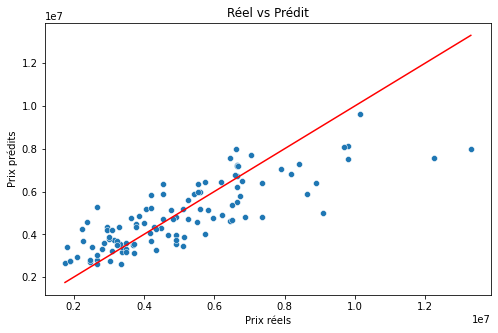

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Prix réels")
plt.ylabel("Prix prédits")
plt.title("Réel vs Prédit")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.show()

## RandomForestRegressor

In [24]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [25]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : {rmse:.2f}")

RMSE : 1383223.46


In [26]:
model.score(X_test,y_test)

0.6214698687357874

## GradientBoostingRegressor

In [34]:
params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}

reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train, y_train)

mse = mean_squared_error(y_test, reg.predict(X_test))
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))

The mean squared error (MSE) on test set: 1802574213367.5149


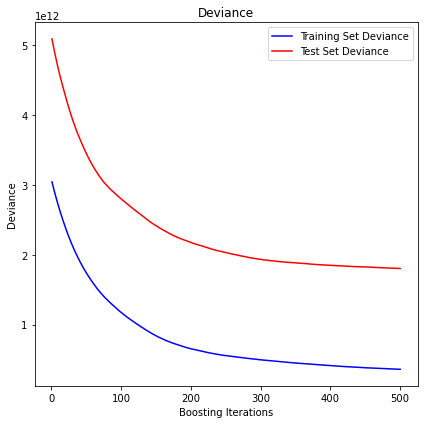

In [35]:
test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(reg.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    reg.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()